## **Assignment 02**

#### **01. Blob Detection**

In [2]:
#import required libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

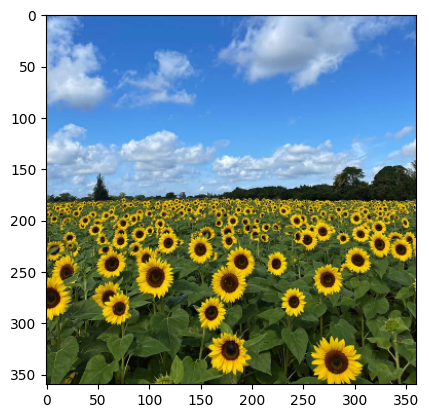

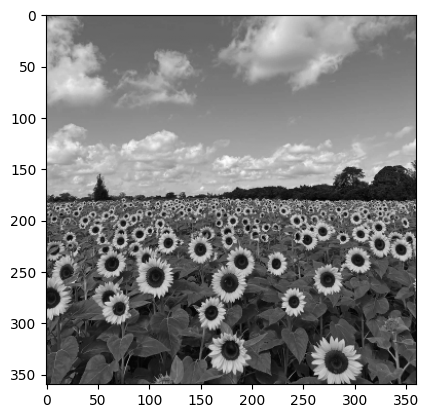

In [11]:
#Read image reducing resolution by factor 4
sunflower_img = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
plt.imshow(sunflower_img[:,:,::-1])
plt.show()

#Convert the image into GrayScale
sunflower_gray = cv.cvtColor(sunflower_img, cv.COLOR_BGR2GRAY)
plt.imshow(sunflower_gray, cmap='gray')
plt.show()

Gaussian Filter derivation

In [3]:
X, Y = np.meshgrid(np.arange(-2,3), np.arange(-2,3))
sigma = 1
gaussian = (1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))
min =np.min((gaussian))
print(np.round(gaussian/min).astype(int))

[[ 1  4  7  4  1]
 [ 4 20 33 20  4]
 [ 7 33 55 33  7]
 [ 4 20 33 20  4]
 [ 1  4  7  4  1]]


In [9]:
G = []
margins = [-2.5,-1.5, -0.5, 0.5, 1.5,2.5]
for j in range(5):
  g = [] 
  for i in range(5):
    X, Y = np.meshgrid(np.arange(margins[i],margins[i+1]+0.001,0.001), np.arange(margins[j],margins[j+1]+0.001,0.001))
    sigma = 1
    gaussian = (1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))
    g.append(np.sum(gaussian))
  G.append(g)

print(np.round(G/np.min(G)).astype(int))


[[ 1  4  6  4  1]
 [ 4 16 25 16  4]
 [ 6 25 40 25  6]
 [ 4 16 25 16  4]
 [ 1  4  6  4  1]]


**Blob Detection**

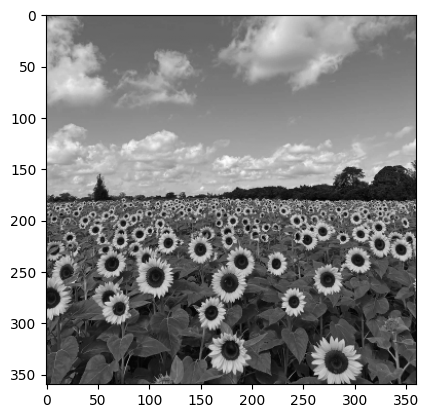

[[ 6.63945457e+17  6.87839493e+17  7.49076931e+17 ...  1.94756220e+17
   2.36433826e+17  2.53299957e+17]
 [ 6.68983350e+17  6.88058021e+17  7.36199039e+17 ...  1.78087658e+17
   2.23109429e+17  2.41249722e+17]
 [ 6.75124741e+17  6.80938065e+17  6.93132955e+17 ...  1.36336779e+17
   1.89127837e+17  2.10221418e+17]
 ...
 [ 8.30923889e+17  7.97672046e+17  6.82555241e+17 ... -3.31514438e+16
   3.93988946e+16  6.20128252e+16]
 [ 8.45380612e+17  8.05450816e+17  6.71784974e+17 ... -4.28804209e+16
   3.75140139e+16  6.34155357e+16]
 [ 8.46095707e+17  8.03813300e+17  6.63664188e+17 ... -4.84881192e+16
   3.47242780e+16  6.18551140e+16]]


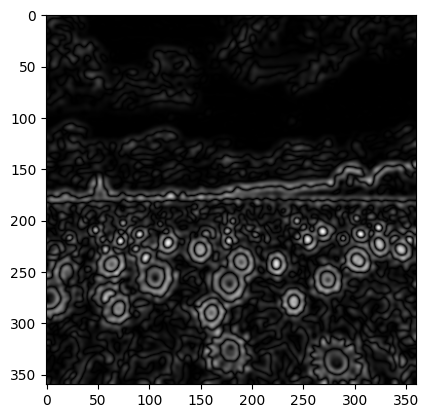

In [ ]:


lap = cv.Laplacian(sunflower_gray, cv.CV_64F, ksize=31)
plt.imshow(np.abs(lap), cmap='gray')
print(lap)


**Laplacian of Gaussian** 
   
The Laplacian of Gaussian is given by,  
  
 $\nabla^2 G(x, y) = \frac{\partial^2 G}{\partial x^2} + \frac{\partial^2 G}{\partial y^2}$.  
   
 $LoG(x,y) =\frac{1}{\pi \sigma^4}
\left[
1 - \frac{x^2 + y^2}{2\sigma^2}
\right]
e^{-\frac{x^2 + y^2}{2\sigma^2}}$




0.49 3
[[-0.27140848 -0.74486332 -0.27140848]
 [-0.74486332  5.521611   -0.74486332]
 [-0.27140848 -0.74486332 -0.27140848]]


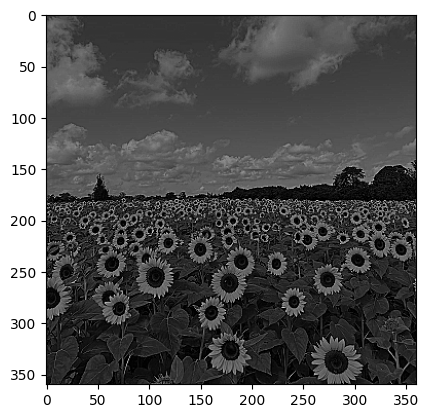

1 7
[[-3.14260486e-04 -2.63207757e-03 -8.57902057e-03 -1.23763620e-02
  -8.57902057e-03 -2.63207757e-03 -3.14260486e-04]
 [-2.63207757e-03 -1.74901468e-02 -3.91926999e-02 -4.30785586e-02
  -3.91926999e-02 -1.74901468e-02 -2.63207757e-03]
 [-8.57902057e-03 -3.91926999e-02  0.00000000e+00  9.65323526e-02
   0.00000000e+00 -3.91926999e-02 -8.57902057e-03]
 [-1.23763620e-02 -4.30785586e-02  9.65323526e-02  3.18309886e-01
   9.65323526e-02 -4.30785586e-02 -1.23763620e-02]
 [-8.57902057e-03 -3.91926999e-02  0.00000000e+00  9.65323526e-02
   0.00000000e+00 -3.91926999e-02 -8.57902057e-03]
 [-2.63207757e-03 -1.74901468e-02 -3.91926999e-02 -4.30785586e-02
  -3.91926999e-02 -1.74901468e-02 -2.63207757e-03]
 [-3.14260486e-04 -2.63207757e-03 -8.57902057e-03 -1.23763620e-02
  -8.57902057e-03 -2.63207757e-03 -3.14260486e-04]]


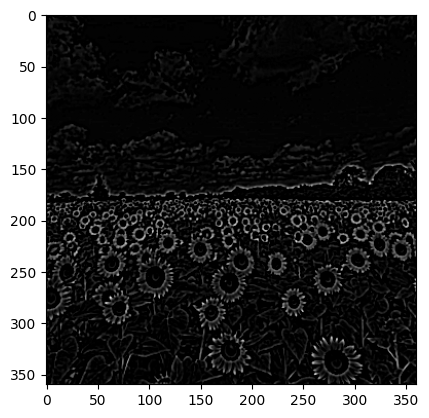

2 13
[[-1.96412803e-05 -6.43310445e-05 -1.64504848e-04 -3.31845109e-04
  -5.36188786e-04 -7.07011010e-04 -7.73522624e-04 -7.07011010e-04
  -5.36188786e-04 -3.31845109e-04 -1.64504848e-04 -6.43310445e-05
  -1.96412803e-05]
 [-6.43310445e-05 -2.01627115e-04 -4.87971972e-04 -9.22278230e-04
  -1.39168823e-03 -1.73562380e-03 -1.85745723e-03 -1.73562380e-03
  -1.39168823e-03 -9.22278230e-04 -4.87971972e-04 -2.01627115e-04
  -6.43310445e-05]
 [-1.64504848e-04 -4.87971972e-04 -1.09313417e-03 -1.85745723e-03
  -2.44954374e-03 -2.67304883e-03 -2.69240991e-03 -2.67304883e-03
  -2.44954374e-03 -1.85745723e-03 -1.09313417e-03 -4.87971972e-04
  -1.64504848e-04]
 [-3.31845109e-04 -9.22278230e-04 -1.85745723e-03 -2.62106369e-03
  -2.44839582e-03 -1.42495796e-03 -8.07344453e-04 -1.42495796e-03
  -2.44839582e-03 -2.62106369e-03 -1.85745723e-03 -9.22278230e-04
  -3.31845109e-04]
 [-5.36188786e-04 -1.39168823e-03 -2.44954374e-03 -2.44839582e-03
   0.00000000e+00  3.99325792e-03  6.03327204e-03  3.99325792

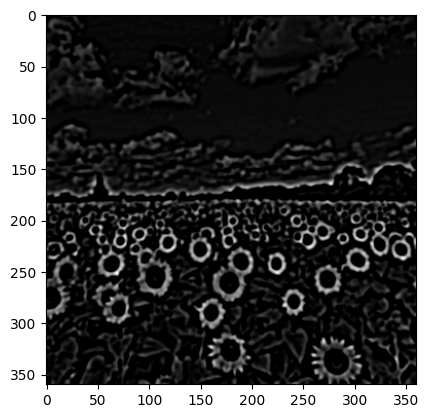

3 19
[[-3.87975908e-06 -8.79858832e-06 -1.78541578e-05 -3.24947848e-05
  -5.32185854e-05 -7.87689374e-05 -1.05913834e-04 -1.30116494e-04
  -1.46831737e-04 -1.52794592e-04 -1.46831737e-04 -1.30116494e-04
  -1.05913834e-04 -7.87689374e-05 -5.32185854e-05 -3.24947848e-05
  -1.78541578e-05 -8.79858832e-06 -3.87975908e-06]
 [-8.79858832e-06 -1.95960696e-05 -3.89414359e-05 -6.92084837e-05
  -1.10409391e-04 -1.58959539e-04 -2.08041461e-04 -2.49686214e-04
  -2.77271245e-04 -2.86874719e-04 -2.77271245e-04 -2.49686214e-04
  -2.08041461e-04 -1.58959539e-04 -1.10409391e-04 -6.92084837e-05
  -3.89414359e-05 -1.95960696e-05 -8.79858832e-06]
 [-1.78541578e-05 -3.89414359e-05 -7.54554148e-05 -1.30116494e-04
  -2.00376949e-04 -2.77271245e-04 -3.48144280e-04 -4.02165372e-04
  -4.34379200e-04 -4.44844482e-04 -4.34379200e-04 -4.02165372e-04
  -3.48144280e-04 -2.77271245e-04 -2.00376949e-04 -1.30116494e-04
  -7.54554148e-05 -3.89414359e-05 -1.78541578e-05]
 [-3.24947848e-05 -6.92084837e-05 -1.30116494e-04 

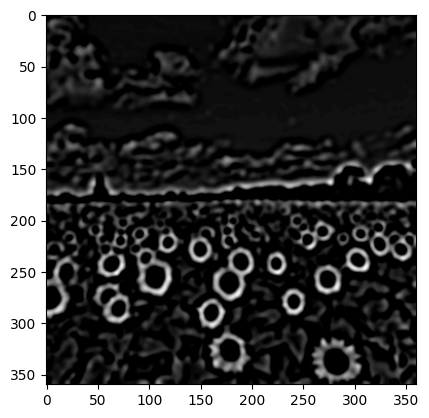

4 25
[[-1.22758002e-06 -2.29252947e-06 -4.02069028e-06 -6.62802926e-06
  -1.02815530e-05 -1.50296015e-05 -2.07403193e-05 -2.70746604e-05
  -3.35117991e-05 -3.94253051e-05 -4.41881881e-05 -4.72761123e-05
  -4.83451640e-05 -4.72761123e-05 -4.41881881e-05 -3.94253051e-05
  -3.35117991e-05 -2.70746604e-05 -2.07403193e-05 -1.50296015e-05
  -1.02815530e-05 -6.62802926e-06 -4.02069028e-06 -2.29252947e-06
  -1.22758002e-06]
 [-2.29252947e-06 -4.23962514e-06 -7.35488222e-06 -1.19791275e-05
  -1.83394641e-05 -2.64332057e-05 -3.59428818e-05 -4.62270800e-05
  -5.64061207e-05 -6.55186479e-05 -7.26909446e-05 -7.72600493e-05
  -7.88268516e-05 -7.72600493e-05 -7.26909446e-05 -6.55186479e-05
  -5.64061207e-05 -4.62270800e-05 -3.59428818e-05 -2.64332057e-05
  -1.83394641e-05 -1.19791275e-05 -7.35488222e-06 -4.23962514e-06
  -2.29252947e-06]
 [-4.02069028e-06 -7.35488222e-06 -1.26016947e-05 -2.02380325e-05
  -3.04982482e-05 -4.31978731e-05 -5.76423894e-05 -7.26909446e-05
  -8.69805146e-05 -9.92282495e-05

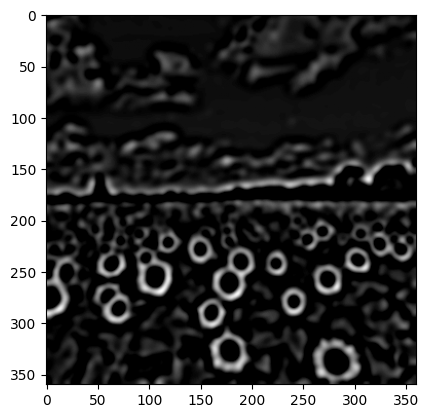

5 31
[[-5.02816777e-07 -8.32941456e-07 -1.32531170e-06 -2.02627092e-06
  -2.97833813e-06 -4.21132411e-06 -5.73268187e-06 -7.51927384e-06
  -9.51293136e-06 -1.16215851e-05 -1.37264329e-05 -1.56940152e-05
  -1.73908077e-05 -1.86975374e-05 -1.95209844e-05 -1.98021792e-05
  -1.95209844e-05 -1.86975374e-05 -1.73908077e-05 -1.56940152e-05
  -1.37264329e-05 -1.16215851e-05 -9.51293136e-06 -7.51927384e-06
  -5.73268187e-06 -4.21132411e-06 -2.97833813e-06 -2.02627092e-06
  -1.32531170e-06 -8.32941456e-07 -5.02816777e-07]
 [-8.32941456e-07 -1.37137893e-06 -2.16750916e-06 -3.28999794e-06
  -4.79826635e-06 -6.72840120e-06 -9.07892719e-06 -1.18001654e-05
  -1.47908031e-05 -1.79037950e-05 -2.09611259e-05 -2.37742331e-05
  -2.61652222e-05 -2.79842349e-05 -2.91203896e-05 -2.95065608e-05
  -2.91203896e-05 -2.79842349e-05 -2.61652222e-05 -2.37742331e-05
  -2.09611259e-05 -1.79037950e-05 -1.47908031e-05 -1.18001654e-05
  -9.07892719e-06 -6.72840120e-06 -4.79826635e-06 -3.28999794e-06
  -2.16750916e-06 -1

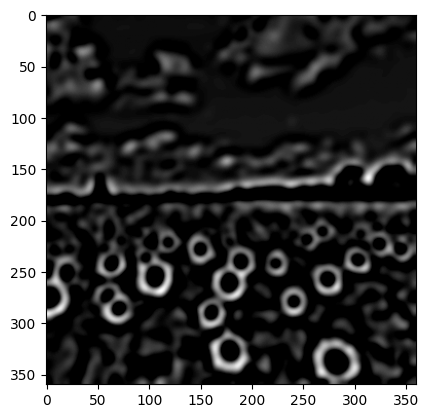

6 37
[[-2.42484943e-07 -3.70318092e-07 -5.49911770e-07 ... -5.49911770e-07
  -3.70318092e-07 -2.42484943e-07]
 [-3.70318092e-07 -5.63175243e-07 -8.32541357e-07 ... -8.32541357e-07
  -5.63175243e-07 -3.70318092e-07]
 [-5.49911770e-07 -8.32541357e-07 -1.22475435e-06 ... -1.22475435e-06
  -8.32541357e-07 -5.49911770e-07]
 ...
 [-5.49911770e-07 -8.32541357e-07 -1.22475435e-06 ... -1.22475435e-06
  -8.32541357e-07 -5.49911770e-07]
 [-3.70318092e-07 -5.63175243e-07 -8.32541357e-07 ... -8.32541357e-07
  -5.63175243e-07 -3.70318092e-07]
 [-2.42484943e-07 -3.70318092e-07 -5.49911770e-07 ... -5.49911770e-07
  -3.70318092e-07 -2.42484943e-07]]


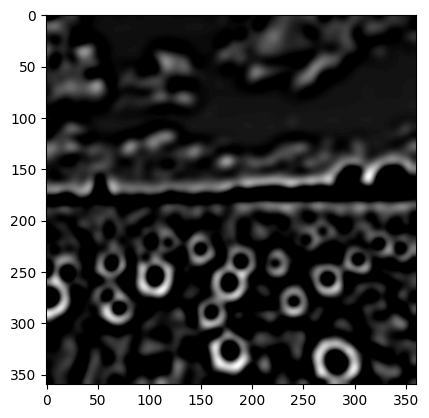

7 43
[[-1.30887333e-07 -1.88479881e-07 -2.65876725e-07 ... -2.65876725e-07
  -1.88479881e-07 -1.30887333e-07]
 [-1.88479881e-07 -2.70587623e-07 -3.80465972e-07 ... -3.80465972e-07
  -2.70587623e-07 -1.88479881e-07]
 [-2.65876725e-07 -3.80465972e-07 -5.33111879e-07 ... -5.33111879e-07
  -3.80465972e-07 -2.65876725e-07]
 ...
 [-2.65876725e-07 -3.80465972e-07 -5.33111879e-07 ... -5.33111879e-07
  -3.80465972e-07 -2.65876725e-07]
 [-1.88479881e-07 -2.70587623e-07 -3.80465972e-07 ... -3.80465972e-07
  -2.70587623e-07 -1.88479881e-07]
 [-1.30887333e-07 -1.88479881e-07 -2.65876725e-07 ... -2.65876725e-07
  -1.88479881e-07 -1.30887333e-07]]


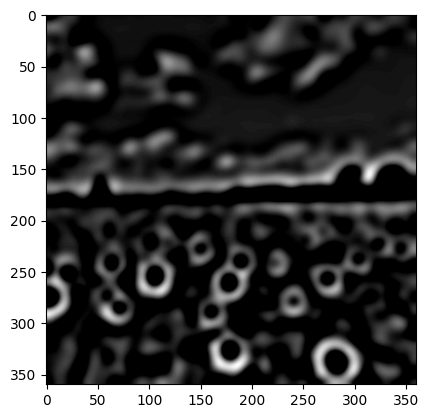

8 49
[[-7.67237514e-08 -1.05679790e-07 -1.43283092e-07 ... -1.43283092e-07
  -1.05679790e-07 -7.67237514e-08]
 [-1.05679790e-07 -1.45227156e-07 -1.96421855e-07 ... -1.96421855e-07
  -1.45227156e-07 -1.05679790e-07]
 [-1.43283092e-07 -1.96421855e-07 -2.64976571e-07 ... -2.64976571e-07
  -1.96421855e-07 -1.43283092e-07]
 ...
 [-1.43283092e-07 -1.96421855e-07 -2.64976571e-07 ... -2.64976571e-07
  -1.96421855e-07 -1.43283092e-07]
 [-1.05679790e-07 -1.45227156e-07 -1.96421855e-07 ... -1.96421855e-07
  -1.45227156e-07 -1.05679790e-07]
 [-7.67237514e-08 -1.05679790e-07 -1.43283092e-07 ... -1.43283092e-07
  -1.05679790e-07 -7.67237514e-08]]


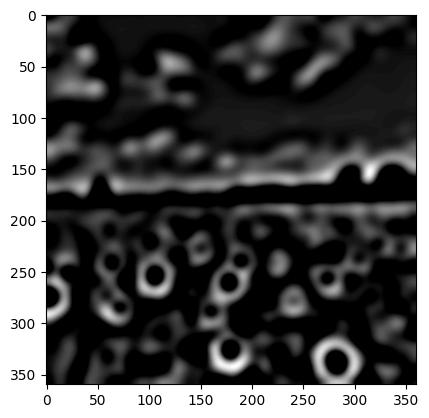

In [77]:
sigma = [0.49, 1, 2, 3, 4, 5, 6, 7, 8]
for s in sigma:
  r = s / np.sqrt(2)
  filter_size = int(6*s + 1)
  print(s, filter_size)
  X, Y = np.meshgrid(np.arange(-filter_size//2+1, filter_size//2+1, 1), np.arange(-filter_size//2+1, filter_size//2+1, 1))
  LoG = (1 / (np.pi * s**4)) * (1 - ((X**2 + Y**2) / (2 * s**2))) * np.exp(- (X**2 + Y**2) / (2 * s**2))
  print(LoG)
  out_img = cv.filter2D(sunflower_gray, -1 , s**2*LoG)
  plt.imshow(out_img, cmap='gray')
  plt.show()


Processing scale with sigma = 1.0
Processing scale with sigma = 1.3333333333333333
Processing scale with sigma = 1.6666666666666665
Processing scale with sigma = 2.0


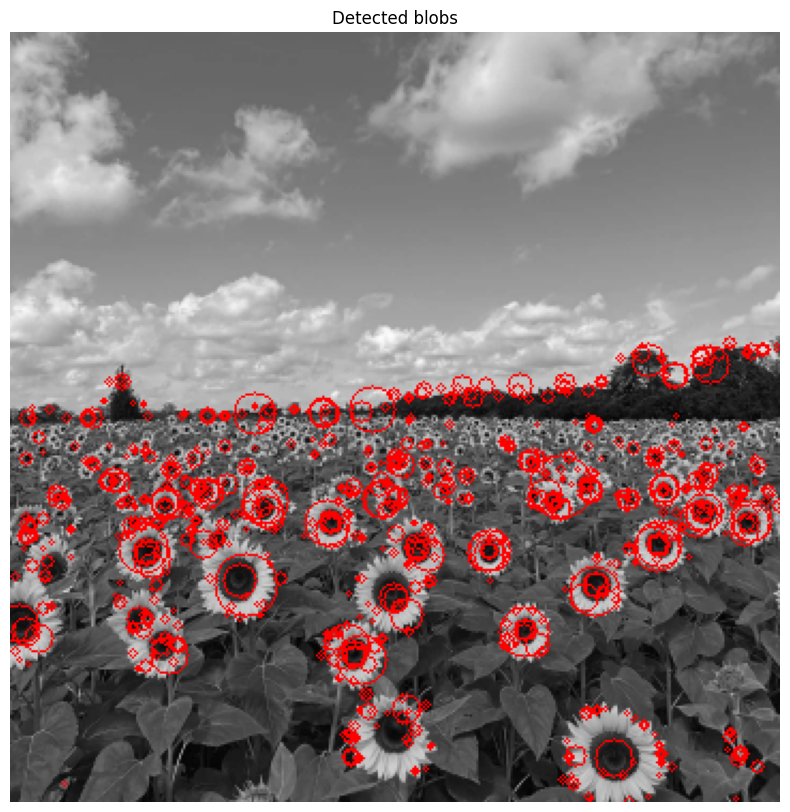

In [59]:
# Select range of sigma
sigma_values = np.linspace(1, 2, 4)
# Threhsold for blob detection
threshold = 0.35

# Store responses of each scale
blob_responses = []

for sigma in sigma_values:
    print(f"Processing scale with sigma = {sigma}")

    # Apply Gaussian blur
    gaussian_blur = cv.GaussianBlur(sunflower_gray, (0, 0), sigma)
    
    # Compute Laplacian of Gaussian (LoG)
    laplacian = cv.Laplacian(gaussian_blur, cv.CV_64F)

    # Get absolute value
    blob_response = np.abs(laplacian)

    # Threshold the response and get contours
    mask = blob_response > threshold * blob_response.max()
    contours, _ = cv.findContours(mask.astype(np.uint8), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # Draw contours as circles
    for contour in contours:
        if len(contour) >= 5:
            # Get the center and radius of the enclosing circle from contour
            (center_x, center_y), radius = cv.minEnclosingCircle(contour)
            # Convert to integers
            center = (int(center_x), int(center_y))
            radius = int(radius)
            blob_responses.append((center, radius, sigma))
            # Draw all detected circles with the specified line thickness
output = cv.cvtColor(sunflower_gray, cv.COLOR_GRAY2BGR)
for blob in blob_responses:
    center, radius, _ = blob
    cv.circle(output, center, radius, (0, 0, 255), 1)

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB), cmap='gray')
plt.axis('off')
plt.title('Detected blobs')
plt.show()




0.71,log filter size for 0.7072135785007072 is : (5, 5)
1.41,log filter size for 1.4144271570014144 is : (9, 9)
2.12,log filter size for 2.1216407355021216 is : (13, 13)
2.83,log filter size for 2.828854314002829 is : (17, 17)
3.54,log filter size for 3.5360678925035365 is : (23, 23)
4.24,log filter size for 4.243281471004243 is : (27, 27)
4.95,log filter size for 4.9504950495049505 is : (31, 31)
5.66,log filter size for 5.657708628005658 is : (35, 35)
6.36,log filter size for 6.364922206506365 is : (39, 39)
7.07,log filter size for 7.072135785007073 is : (43, 43)


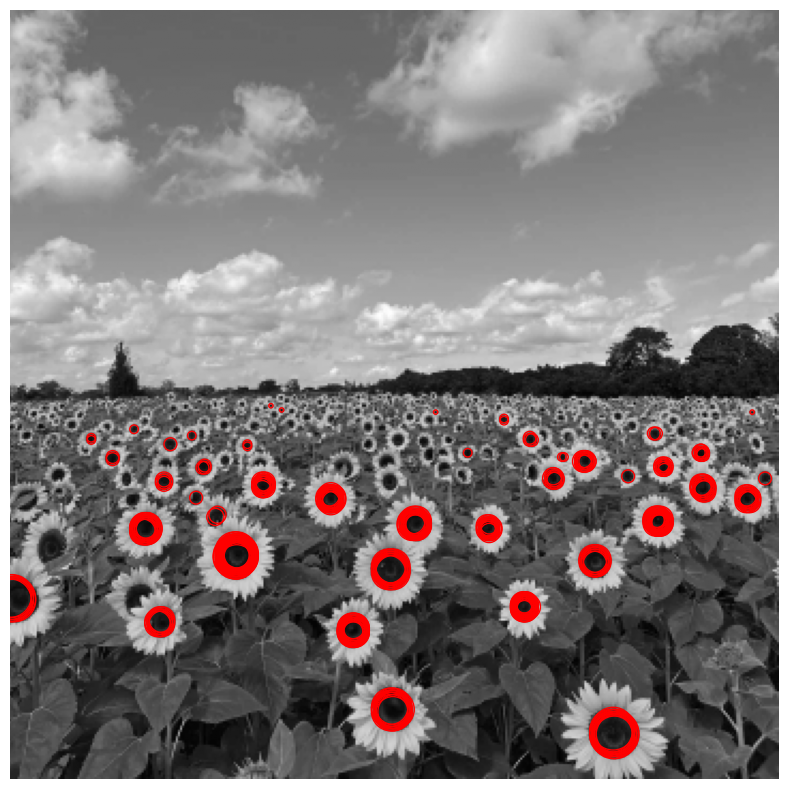

In [40]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load the image and convert it to grayscale
img1 = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY) / 255

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10), frameon=False)
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Get the current axes object
ax = plt.gca()

patches = []
labels = []

# Detect blobs at different sigma values
for r in range(1, 11):
    sigma = r / 1.414
    print(f"{sigma:.2f}", end=",")
    hw = round(3 * sigma)  # Half width of the kernel
    X, Y = np.meshgrid(np.arange(-hw, hw + 1, 1), np.arange(-hw, hw + 1, 1))

    # Calculate Laplacian of Gaussian (LoG) filter
    LOG = ((X**2 + Y**2) / (2 * sigma**2) - 1) * np.exp(-(X**2 + Y**2) / (2 * sigma**2)) / (np.pi * sigma**4)
    print(f'log filter size for {sigma} is :',LOG.shape)
    
    # Scale the filter and apply it to the image
    LOG = sigma**2 * LOG
    img1_log = np.square(cv.filter2D(gray, -1, LOG))

    # Detect maxima manually
    coordinates = []
    (H, W) = img1_log.shape
    k = 1  # Neighborhood size
    threshold = 0.1  # Threshold for maxima detection
    for i in range(k, H - k):
        for j in range(k, W - k):
            slice_img = img1_log[i - k:i + k + 1, j - k:j + k + 1]
            if np.max(slice_img) >= threshold:
                # Get coordinates of the maximum point
                x, y = np.unravel_index(slice_img.argmax(), slice_img.shape)
                coordinates.append((i + x - k, j + y - k))
    coordinates = set(coordinates)

    # Plot circles around detected blobs
    for x, y in coordinates:
        c = plt.Circle((y, x), sigma * 1.414, color='r', linewidth=1, fill=False)
        ax.add_patch(c)
    patches.append(c)
    ax.plot()

ax.set_xlim([0, img1.shape[1]])
ax.set_ylim([img1.shape[0], 0])

# Add legend and title
plt.axis('off')
plt.show()